---
title: "Testing Shot-Frugal Optimizers for VQAs"
author: "Marc-Justin Scheffler"
date: "2026-08-21"
categories: [code, optimizers]
image: "ShotFrugalOptPreview.png"
image-width: "1cm"
image-height: "1cm"
format:
  html:
    code-fold: true
    code-summary: "Show implementation"
    toc: true
    cap-location: bottom
jupyter: blogqa
execute:
  enabled: false
---


[Variational quantum algorithms](https://doi.org/10.1038/s42254-021-00348-9) (VQAs) use a classical optimizer to tune a parameterized quantum circuit from repeated estimates of a quantum objective, for example to approximate the ground state of a given Hamiltonian. Because expectation values and gradient components must be estimated from a finite number of measurements, these estimates inevitably contain statistical noise. Studies by [Scriva *et al.*](https://doi.org/10.1103/PhysRevA.109.032408) and [Bärligea *et al.*](https://doi.org/10.1103/rgyh-8xw8) show that this measurement noise can pose a serious obstacle to scalable optimization. An effective optimizer must therefore decide not only where to move in parameter space, but also how to allocate the available measurement budget at each step, balancing estimation accuracy against sampling cost.

This research tutorial implements and tests three proposals for adapting that measurement effort in a shot-frugal way:

- **[iCANS](https://doi.org/10.22331/q-2020-05-11-263)** assigns a separate number of shots to each gradient component.
- **[gCANS](https://arxiv.org/abs/2108.10434)** chooses those allocations using the expected progress of the complete gradient update.
- **[Rosalin](https://arxiv.org/abs/2004.06252)** combines adaptive gradient shots with random sampling of Hamiltonian terms.


## Why adapt the number of shots?

For a parameterized circuit $U(\boldsymbol{\theta})$ and Hamiltonian $H$, a typical VQA objective is

$$
E(\boldsymbol{\theta})
=\langle 0|U^\dagger(\boldsymbol{\theta})
H U(\boldsymbol{\theta})|0\rangle.
$$

If a parameter enters through a Pauli rotation, its derivative can be evaluated with the parameter-shift rule,

$$
\partial_i E(\boldsymbol{\theta})
=\frac{E(\boldsymbol{\theta}+\tfrac{\pi}{2}\mathbf e_i)
-E(\boldsymbol{\theta}-\tfrac{\pi}{2}\mathbf e_i)}{2}.
$$

The formula is analytic, but its two expectation values are still estimated from measurements. With $s_i$ shots, the estimator variance generally decreases as $1/s_i$. Small allocations make an iteration cheap but noisy; large allocations produce a more reliable direction but may spend measurements where they do not improve the final solution.

iCANS, gCANS, and Rosalin formalize this trade-off by maximizing a model of expected objective improvement per shot. Their allocation formulas assume a fixed learning rate $\alpha<2/L$, where $L$ bounds the Lipschitz constant of the objective gradient. In practice, the gradient and variance information required by the formulas must themselves be estimated.


In [1]:
import tequila as tq
import numpy as np
import matplotlib.pyplot as plt

SEED = 7
np.random.seed(SEED)

## iCANS (individual Coupled Adaptive Number of Shots)

The iCANS optimizer was introduced by [Kübler *et al.*](https://doi.org/10.22331/q-2020-05-11-263). It estimates each partial derivative independently and assigns it a shot count based on its estimated variance and magnitude. In its simplest form, the allocation has the structure

$$
s_i
=\frac{2L\alpha}{2-L\alpha}
\frac{S_i}{g_i^2},
$$

where $g_i$ estimates the $i$th gradient component and $S_i$ estimates the corresponding single-shot variance. Exponential moving averages stabilize both quantities. A cap prevents nearly converged components, for which $g_i\approx0$, from consuming the entire budget. iCANS2 additionally reduces the learning rate along a component when the estimated expected gain is not positive.

In the implementation below, the parameter-shift evaluations are sampled, while the required single-shot variances are obtained from exact first and second moments on the simulator. While this is a useful simulation oracle, it is not a free operation on hardware, as a device implementation would need to estimate these moments and include their measurements in the resource accounting.


In [2]:
class History:
    def __init__(self):
        self.energies = []
        self.angles = []

    def plot(self, key):
        if not hasattr(self, key):
            raise ValueError(f"No history entry '{key}'")

        data = getattr(self, key)

        if key == "angles":
            param_keys = list(data[0].keys())
            for k in param_keys:
                plt.plot([a[k] for a in data], label=str(k))
            plt.legend()
        else:
            plt.plot(data)

        plt.xlabel("iteration")
        plt.ylabel(key)
        plt.show()   

class ICANSResult:
    def __init__(self):
        self.energy = None
        self.angles = None
        self.nfev = 0
        self.history = History()
        self.niter = 0


def iCANS(objective, lr, initial_values, s_min, N, L, mu, b, icans1=True):
    result = ICANSResult()
    theta = initial_values.copy()
    s_tot = 0
    s = np.full(len(theta), s_min)
    chi_0 = np.full(len(theta), 0.0)
    xi_0 = np.full(len(theta), 0.0)
    k = 0
    f = tq.compile(objective, backend="qulacs")
    expectation = objective.get_expectationvalues()[0]
    fsq = tq.compile(
        tq.ExpectationValue(U=expectation.U, H=expectation.H[0] ** 2),
        backend="qulacs",
    )
    while s_tot < N:
        
        g = np.zeros(len(theta))
        for i, key in enumerate(theta):
            theta_plus = theta.copy()
            theta_minus = theta.copy()
            
            theta_plus[key]  += np.pi/2
            theta_minus[key] -= np.pi/2
            
            g[i] = (f(theta_plus, samples=s[i]) - f(theta_minus, samples=s[i])) / 2
            result.nfev += 2


        S = np.zeros(len(theta))
        for i, key in enumerate(theta):
            theta_plus = theta.copy()
            theta_minus = theta.copy()
            
            theta_plus[key]  += np.pi/2
            theta_minus[key] -= np.pi/2


            mean_plus = f(theta_plus)
            second_moment_plus = fsq(theta_plus)
            mean_minus = f(theta_minus)
            second_moment_minus = fsq(theta_minus)
            result.nfev += 4

            variance_plus = second_moment_plus - mean_plus**2
            variance_minus = second_moment_minus - mean_minus**2
            S[i] = abs((variance_plus + variance_minus) / 4)

        
        s_tot = s_tot + 2 * np.sum(s)
        xi_0 = mu * xi_0 + (1 - mu) * S
        chi_0 = mu * chi_0 + (1 - mu) * g
        xi = xi_0 / (1 - np.power(mu, k + 1))
        chi = chi_0 / (1 - np.power(mu, k + 1))

        epsilon = np.full(len(theta), 0.0)
        for i, key in enumerate(theta):
            if icans1:
                step_lr = lr
            else:
                denominator = L * (
                    g[i] ** 2 + S[i] / max(s[i], 1) + b * mu**k
                )
                lr_check = g[i] ** 2 / max(denominator, 1e-12)
                step_lr = min(lr, lr_check)

            theta[key] = theta[key] - step_lr * g[i]
            denominator = chi[i] ** 2 + b * mu**k
            s[i] = np.ceil(
                ((2 * L * lr) / (2 - L * lr))
                * (xi[i] / max(denominator, 1e-12))
            )
            epsilon[i] = (1.0 / s[i]) * (
                (lr - L * lr**2 / 2) * chi[i] ** 2
                - (L * lr**2 / (2 * s[i])) * xi[i]
            )

        best_component = int(np.argmax(epsilon))
        s_cap = max(s_min, s[best_component])
        s = np.clip(s, s_min, s_cap)
        k += 1

        result.niter += 1

        energy = f(theta)

        result.nfev += 1

        result.history.energies.append(energy)
        result.history.angles.append(theta.copy()) 
    result.angles = theta
    f = tq.compile(objective, backend="qulacs")
    result.energy = f(theta)
    result.nfev += 1

    return result

As a small Tequila example, we first define a three-qubit variational objective with four trainable angles. The same starting point and nominal budget are reused for all three methods.

In [3]:
# objective to optimize
a = tq.Variable(name="a")*tq.numpy.pi
b = tq.Variable(name="b")*tq.numpy.pi
c = tq.Variable(name="c")*tq.numpy.pi
d = tq.Variable(name='d')*tq.numpy.pi

U = tq.gates.Ry(tq.numpy.pi/2,0) +tq.gates.Ry(tq.numpy.pi/3,1)+tq.gates.Ry(tq.numpy.pi/4,2)
U += tq.gates.Rz('a',0)+tq.gates.Rz('b',1)
U += tq.gates.CNOT(control=0,target=1)+tq.gates.CNOT(control=1,target=2)
U += tq.gates.Ry('c',1) +tq.gates.Rx('d',2)
U += tq.gates.CNOT(control=0,target=1)+tq.gates.CNOT(control=1,target=2)

H = tq.paulis.Y(0)*tq.paulis.X(1)*tq.paulis.Y(2)
O = tq.ExpectationValue(H=H, U=U)


# dictionary of parameters
rng = np.random.default_rng(SEED)
init = {k: rng.uniform(-2, 2) for k in ['a', 'b', 'c', 'd']}

# use of icans
res_icans = iCANS(O, 0.1, init, 10, 10000, 1.0, 0.9, 0.01, icans1=False)

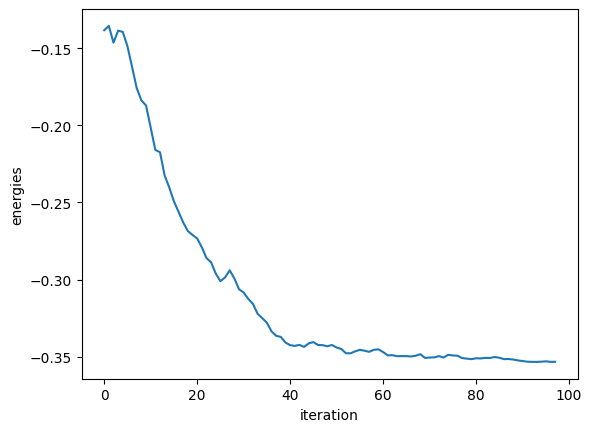

energy:-0.3532708765185349


In [4]:
# showing energy results
res_icans.history.plot("energies")
print(f"energy:{res_icans.energy}")

The trace is noisy because each parameter-shift expectation is sampled. Here the objective is the expectation value of one Pauli string and is bounded below by $-1$; a final value well above that bound shows that this limited-budget run is not converged. An individual run is therefore not enough to rank stochastic optimizers. Meaningful comparisons require repeated runs from controlled initial conditions and should be considered against cumulative measurement cost rather than iteration alone.


## gCANS (global Coupled Adaptive Number of Shots)

[Gu *et al.*](https://arxiv.org/abs/2108.10434) observed that optimizing every component independently need not maximize the efficiency of the complete update. gCANS instead maximizes a lower bound on the expected global improvement divided by the total shots used in the iteration. Its allocation is

$$
s_i
=\frac{2L\alpha}{2-L\alpha}
\frac{\sigma_i\sum_j\sigma_j}
{\|\nabla E(\boldsymbol{\theta})\|_2^2},
$$

where $\sigma_i$ is the single-shot standard deviation of the $i$th gradient estimator. The coupling through the full gradient norm and the sum of standard deviations is exactly the difference from iCANS. The published convergence result assumes a convex objective. As VQA landscapes are generally nonconvex, applications outside that regime remain heuristic even when the allocation formula is implemented exactly.

In [5]:
class History:
    def __init__(self):
        self.energies = []
        self.angles = []

    def plot(self, key):
        if not hasattr(self, key):
            raise ValueError(f"No history entry '{key}'")

        data = getattr(self, key)

        if key == "angles":
            param_keys = list(data[0].keys())
            for k in param_keys:
                plt.plot([a[k] for a in data], label=str(k))
            plt.legend()
        else:
            plt.plot(data)

        plt.xlabel("iteration")
        plt.ylabel(key)
        plt.show()   

class GCANSResult:
    def __init__(self):
        self.energy = None
        self.angles = None
        self.nfev = 0
        self.history = History()
        self.niter = 0


def gCANS(objective, lr, initial_values, s_min, N, L, mu):
    result = GCANSResult()
    theta = initial_values.copy()
    s_tot = 0
    s = np.full(len(theta), s_min)
    chi_0 = np.full(len(theta), 0.0)
    xi_0 = np.full(len(theta), 0.0)
    k = 0
    f = tq.compile(objective, backend="qulacs")
    expectation = objective.get_expectationvalues()[0]
    fsq = tq.compile(
        tq.ExpectationValue(U=expectation.U, H=expectation.H[0] ** 2),
        backend="qulacs",
    )
    while s_tot < N:
        
        g = np.zeros(len(theta))
        for i, key in enumerate(theta):
            theta_plus = theta.copy()
            theta_minus = theta.copy()
            
            theta_plus[key]  += np.pi/2
            theta_minus[key] -= np.pi/2
            
            g[i] = (f(theta_plus, samples=s[i]) - f(theta_minus, samples=s[i])) / 2
            result.nfev += 2


        S = np.zeros(len(theta))
        for i, key in enumerate(theta):
            theta_plus = theta.copy()
            theta_minus = theta.copy()
            
            theta_plus[key]  += np.pi/2
            theta_minus[key] -= np.pi/2


            mean_plus = f(theta_plus)
            second_moment_plus = fsq(theta_plus)
            mean_minus = f(theta_minus)
            second_moment_minus = fsq(theta_minus)
            result.nfev += 4

            variance_plus = second_moment_plus - mean_plus**2
            variance_minus = second_moment_minus - mean_minus**2
            S[i] = abs((variance_plus + variance_minus) / 4)

        s_tot = s_tot + 2 * np.sum(s)

        xi_0 = mu * xi_0 + (1 - mu) * S
        chi_0 = mu * chi_0 + (1 - mu) * g
        xi = xi_0 / (1 - np.power(mu, k + 1))
        chi = chi_0 / (1 - np.power(mu, k + 1))

        sigma = np.sqrt(np.maximum(xi, 0.0))
        gradient_norm_squared = max(np.sum(chi**2), 1e-12)
        for i, key in enumerate(theta):
            theta[key] = theta[key] - lr * g[i]
            s[i] = max(
                np.ceil(
                    ((2 * L * lr) / (2 - L * lr))
                    * (sigma[i] * np.sum(sigma) / gradient_norm_squared)
                ),
                s_min,
            )

        k += 1

        result.niter += 1

        energy = f(theta)

        result.nfev += 1

        result.history.energies.append(energy)
        result.history.angles.append(theta.copy()) 
    result.angles = theta
    f = tq.compile(objective, backend="qulacs")
    result.energy = f(theta)
    result.nfev += 1

    return result


In [6]:
# we will use the same objective as before
res_gcans = gCANS(O, 0.1, init, 10, 10000, 1.0, 0.9)

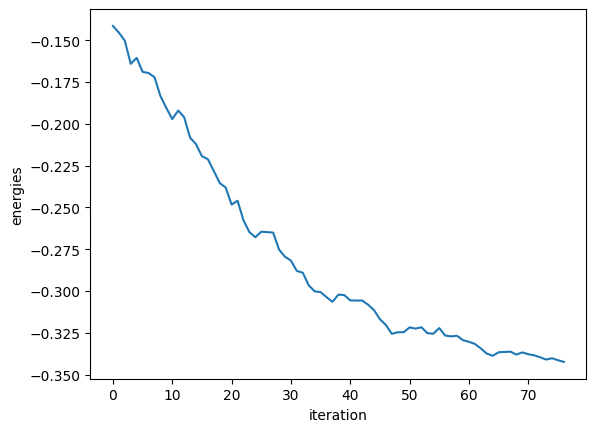

energy:-0.3424553953554086


In [7]:
# showing energy results
res_gcans.history.plot("energies")
print(f"energy:{res_gcans.energy}")

At the same nominal budget, this one gCANS trajectory reaches a similar energy to the iCANS trajectory. However, the visual similarity does not establish equivalent efficiency as the two methods can distribute their shots differently across iterations and gradient components, and stochastic differences must be quantified over repeated, paired runs.


## Rosalin (Random operator sampling for adaptive learning with individual number of shots)

Suppose

$$
H=\sum_{j=1}^{M}c_jP_j,
$$

with Pauli strings $P_j$. Measuring every term at least once creates a shot floor that grows with $M$. [Arrasmith *et al.*](https://arxiv.org/abs/2004.06252) proposed drawing a term with probability

$$
p_j=\frac{|c_j|}{\sum_k|c_k|}
$$

and using the single-shot estimator

$$
Y=\frac{c_j r_j}{p_j},
\qquad r_j\in\{-1,+1\}.
$$

Because $\mathbb E[Y]=\langle H\rangle$, even one randomly selected operator gives an unbiased, although potentially high-variance, estimate. Rosalin combines this weighted operator sampling with iCANS. The hybrid variant deterministically assigns the integer part of $p_js$ and distributes only the remaining shots randomly, interpolating between the low-shot random regime and weighted deterministic sampling.

The implementation keeps each sampled Pauli operator coefficient-free and applies $c_j/p_j$ to its measurement result. This separation is essential for unbiasedness.


In [8]:
class History:
    def __init__(self):
        self.energies = []
        self.angles = []

    def plot(self, key):
        if not hasattr(self, key):
            raise ValueError(f"No history entry '{key}'")

        data = getattr(self, key)

        if key == "angles":
            param_keys = list(data[0].keys())
            for k in param_keys:
                plt.plot([a[k] for a in data], label=str(k))
            plt.legend()
        else:
            plt.plot(data)

        plt.xlabel("iteration")
        plt.ylabel(key)
        plt.show()   

class RosalinResult:
    def __init__(self):
        self.energy = None
        self.angles = None
        self.nfev = 0
        self.history = History()
        self.niter = 0


def estimate_H(theta, s_tot, c, compiled_terms, hybrid):
    E = np.full(s_tot, 0.0)
    l = 0
    s = np.full(len(c), 0)

    p = np.abs(c) / np.sum(np.abs(c))
    if hybrid and np.floor(min(p * s_tot)) > 0:
        s = np.floor(p * s_tot)
        s_det = np.sum(s)
    else:
        s_det = 0
    s_rand = s_tot - s_det
    m = np.random.multinomial(s_rand, p)
    s += m

    for i in range(len(c)):
        for j in range(int(s[i])):
            r = compiled_terms[i](theta, samples=1)
            E[l] = (c[i]*r) / p[i]
            l += 1
    return E

def iEvaluate(theta, s_tot, key, c, compiled_terms, hybrid):
    theta_plus = theta.copy()
    theta_minus = theta.copy()
            
    theta_plus[key]  += np.pi/2
    theta_minus[key] -= np.pi/2

    E_plus = estimate_H(theta_plus, s_tot, c, compiled_terms, hybrid)
    E_minus = estimate_H(theta_minus, s_tot, c, compiled_terms, hybrid)

    g = np.sum(E_plus - E_minus) / (2 * s_tot)

    S = np.sum([((E_plus[j] - E_minus[j]) / 2)**2 - g**2 for j in range(s_tot)]) / (s_tot - 1)

    return g, S


def rosalin(objective, lr, initial_values, s_min, M, L, mu, b, hybrid=True):
    result = RosalinResult()
    theta = initial_values.copy()
    s_tot = 0
    s = np.full(len(theta), s_min)
    chi = np.full(len(theta), 0.0)
    xi = np.full(len(theta), 0.0)
    chi_0 = np.full(len(theta), 0.0)
    xi_0 = np.full(len(theta), 0.0)
    epsilon = np.full(len(theta), 0.0)
    g = np.full(len(theta), 0.0)
    S = np.full(len(theta), 0.0)
    k = 0
    f = tq.compile(objective, backend="qulacs")
    h = []
    c = []
    H = objective.get_expectationvalues()[0].H
    for hi, ci in H[0].items():
        hi_dict = {idx: pauli for idx, pauli in hi}
        hi_op = tq.QubitHamiltonian.from_paulistrings([tq.PauliString(hi_dict, 1.0)])
        h.append(hi_op)
        c.append(ci)
    c = np.array(c)
    compiled_terms = [
        tq.compile(tq.ExpectationValue(U=objective.get_expectationvalues()[0].U, H=term), backend="qulacs")
        for term in h
    ]
    while s_tot < M:
        s_tot = s_tot + 2 * np.sum(s)

        # Estimate the complete gradient at one common parameter vector.
        for l, key in enumerate(theta):
            g[l], S[l] = iEvaluate(
                theta, s[l], key, c, compiled_terms, hybrid
            )
            result.nfev += 2 * s[l]
            xi_0[l] = mu * xi_0[l] + (1-mu) * S[l]
            chi_0[l] = mu * chi_0[l] + (1-mu) * g[l]
            xi[l] = xi_0[l] / (1 - mu**(k+1))
            chi[l] = chi_0[l] / (1 - mu**(k+1))

        # Apply the vector update only after every component has been estimated.
        for l, key in enumerate(theta):
            theta[key] = theta[key] - lr * g[l]
            s[l] = max(np.ceil(((2*L*lr) / (2-L*lr)) * (xi[l] / (np.power(chi[l], 2)+b*np.power(mu, k)))), 1)
            epsilon[l] = (1.0 / s[l]) * ((lr - (L*np.power(lr, 2) / 2)) * np.power(chi[l], 2) - (L*np.power(lr, 2) / (2 * s[l])) * xi[l])
        best_component = int(np.argmax(epsilon))
        s_cap = max(s_min, s[best_component])
        s = np.clip(s, s_min, s_cap)
        k += 1
        result.niter += 1

        energy = f(theta)

        result.nfev += 1

        result.history.energies.append(energy)
        result.history.angles.append(theta.copy())  
    result.angles = theta
    f = tq.compile(objective, backend="qulacs")
    result.energy = f(theta)
    result.nfev += 1

    return result


In [9]:
# we will use the same objective as before again
res_rosalin = rosalin(O, 0.1, init, 10, 10000, 1.0, 0.9, 0.01, hybrid=True)

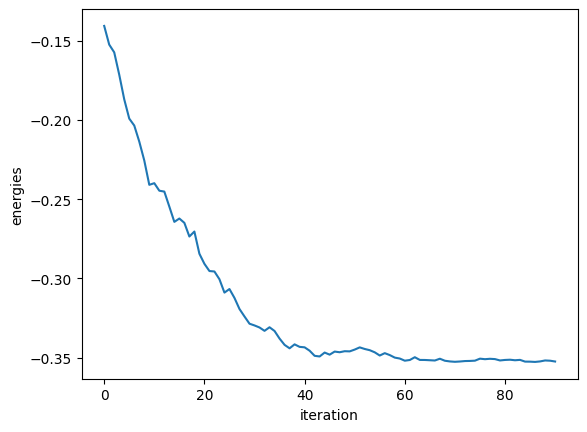

energy:-0.35244146833352025


In [10]:
# showing energy results
res_rosalin.history.plot("energies")
print(f"energy:{res_rosalin.energy}")

Rosalin reaches the same broad energy range in this small test. Its larger wall-clock overhead comes mostly from sampling and dispatching individual Hamiltonian terms in Python. It should not be interpreted as a measurement-cost comparison.

## What differs between the methods?

| Method | Adaptive level | Main attraction | Main sensitivity |
|---|---|---|---|
| iCANS | Gradient component | Directs precision toward locally useful partial derivatives | Allocation becomes unstable when estimated gradients are close to zero |
| gCANS | Full gradient plus components | Coordinates allocations using the progress of the whole update | Depends on a reliable global gradient norm and inherits convex-theory assumptions |
| Rosalin | Gradient component and Hamiltonian term | Avoids measuring every Hamiltonian term in the low-shot regime | Adds operator-sampling variance and substantial implementation overhead |

All three methods target *measurement* cost. Wall-clock runtime in this notebook is not a faithful estimator for that cost: Python loops, repeated compilation, simulator overhead, and the number of Pauli terms can dominate runtime independently of the nominal shot budget.


## Scaling experiment

The original scaling experiment was rerun after validating the estimators and allocation rules. The corrected implementation now applies each Hamiltonian coefficient exactly once in Rosalin, uses standard deviations in the gCANS allocation, selects the iCANS/Rosalin cap from the component with the largest expected gain per shot, and updates all Rosalin parameters from a gradient evaluated at one common parameter vector.

The rerun also changes the experimental bookkeeping. Variances are estimated from the same finite samples as the gradients, every circuit shot is counted, and an update is performed only if it fits within the remaining budget. Exact energies are evaluated after an update only for reporting; they are never supplied to the optimizer. Each stochastic trajectory is run once up to the largest budget, and its state at each smaller budget is read from that same trajectory.

### Design

For each size $n\in\{3,4,5,6,7\}$, we draw one Sherrington--Kirkpatrick Hamiltonian

$$
H=\sum_{i<j}J_{ij}Z_iZ_j,
$$

with Gaussian couplings and normalize it by $\sum_{i<j}|J_{ij}|$. We optimize a depth-three hardware-efficient circuit containing independent $R_x$ and $R_y$ rotations on every qubit followed by a linear layer of controlled-$Z$ gates. The experiment uses ten matched random initializations per system size and cumulative budgets of $5{,}000$, $10{,}000$, $20{,}000$, $50{,}000$, and $100{,}000$ shots. The optimizer parameters are $\alpha=0.1$, $s_{\min}=10$, $L=1$, $\mu=0.99$, and $b=10^{-6}$ where applicable. Here, $L=1$ is a shared empirical allocation parameter after normalization, not a certified global Lipschitz bound for the nonconvex circuit objective.

All terms in this Hamiltonian are diagonal in the computational basis. Consequently, iCANS and gCANS estimate the complete Hamiltonian from every measured bit string, whereas Rosalin deliberately samples one Hamiltonian term per shot. The plotted quantity is the relative energy gap

$$
\frac{E(\boldsymbol{\theta})-E_0}{|E_0|},
$$

where $E_0$ is obtained by exact enumeration. Curves show the median over the ten runs and shaded regions show the interquartile range. The [raw trajectories](optimizer_scaling_runs.csv), [aggregate statistics](optimizer_scaling_summary.csv), and [complete experiment configuration](optimizer_scaling_metadata.json) are included with the tutorial.

::: {.callout-note title="What the uncertainty band represents"}
The ten runs vary the initialization and measurement samples, but use the same SK instance for a given $n$. The bands therefore quantify run-to-run variability on those five instances, not variability across the SK ensemble.
:::

### iCANS

![Median relative energy gap for iCANS; shaded regions show the interquartile range over ten runs.](iCANS_scaling.png)

For every system size, additional shots lower the median energy gap. The required budget nevertheless grows rapidly with $n$: at $100{,}000$ shots, the median gap increases from approximately $0.005$ for three qubits to $0.56$ for seven qubits. The widening band for several intermediate sizes also shows why a single optimization trace would give a fragile impression of performance.

### gCANS

![Median relative energy gap for gCANS; shaded regions show the interquartile range over ten runs.](gCANS_scaling.png)

gCANS displays the same dominant size dependence. At the largest budget, its median gaps range from approximately $0.005$ at three qubits to $0.58$ at seven qubits. It often reaches a given budget in fewer iterations than iCANS for the smallest systems because its global rule assigns more shots to an iteration, but this does not translate into a consistent energy advantage at fixed total shots.

### Rosalin

![Median relative energy gap for Rosalin; shaded regions show the interquartile range over ten runs.](Rosalin_scaling.png)

Rosalin also improves steadily with the measurement budget, but it does not consistently outperform the other methods. This result is unsurprising for the present Hamiltonians: because all $Z_iZ_j$ terms can be inferred from the same computational-basis measurement, ordinary Hamiltonian sampling already extracts every term from each shot. Rosalin's operator sampling is designed to be most useful when estimating a Hamiltonian requires many distinct measurement settings, so this commuting Ising benchmark removes much of its intended advantage.

### Direct comparison

![Median relative energy gap at 100,000 shots; error bars show the interquartile range.](optimizer_comparison.png)

The comparison at $100{,}000$ shots has no stable winner. gCANS is marginally best for $n=3$, iCANS for $n=4,5,7$, and Rosalin for $n=6$, but the interquartile ranges overlap strongly in most cases. These small changes in ordering should therefore not be interpreted as evidence of algorithmic superiority. The robust observation is instead the common scaling trend: a budget that nearly solves the three- and four-qubit instances still leaves a substantial optimization gap for six and seven qubits.

## What can we conclude?

1. **Adaptive shot allocation does not eliminate the scaling problem.** All three optimizers benefit from more measurements, yet their accuracy at a fixed budget deteriorates markedly as the circuit and problem grow.
2. **No optimizer wins this benchmark consistently.** Differences between median curves are generally smaller than the run-to-run spread.
3. **The measurement structure matters.** Rosalin's term-sampling mechanism offers little inherent advantage for a fully commuting Ising Hamiltonian whose terms can be measured together. A molecular or otherwise noncommuting Hamiltonian would test a different and more favorable regime for Rosalin.
4. **Shot counts and iteration counts answer different questions.** The global gCANS allocation can use fewer, more precise updates, which may matter when changing or submitting circuits has appreciable overhead even if the final energy at a fixed shot budget is similar.

This remains a compact tutorial experiment rather than a definitive optimizer benchmark. A broader study should repeat the analysis over many problem instances, tune hyperparameters without using the test data, include fixed-shot SGD and SPSA baselines, and separately study Hamiltonians with many noncommuting measurement groups.

## References

- M. Cerezo, A. Arrasmith, R. Babbush, S. C. Benjamin, S. Endo, K. Fujii, J. R. McClean, K. Mitarai, X. Yuan, L. Cincio, and P. J. Coles, [Variational Quantum Algorithms](https://doi.org/10.1038/s42254-021-00348-9), *Nature Reviews Physics* **3**, 625–644 (2021).
- G. Scriva, N. Astrakhantsev, S. Pilati, and G. Mazzola, [Challenges of Variational Quantum Optimization with Measurement Shot Noise](https://doi.org/10.1103/PhysRevA.109.032408), *Physical Review A* **109**, 032408 (2024).
- A. Bärligea, B. Poggel, and J. M. Lorenz, [Scalability challenges in variational quantum optimization under stochastic noise](https://doi.org/10.1103/rgyh-8xw8), *Physical Review A* **112**, 032407 (2025).
- J. M. Kübler, A. Arrasmith, L. Cincio, and P. J. Coles, [An Adaptive Optimizer for Measurement-Frugal Variational Algorithms](https://doi.org/10.22331/q-2020-05-11-263), *Quantum* **4**, 263 (2020).
- A. Arrasmith, L. Cincio, R. D. Somma, and P. J. Coles, [Operator Sampling for Shot-frugal Optimization in Variational Algorithms](https://arxiv.org/abs/2004.06252), arXiv:2004.06252 (2020).
- A. Gu, A. Lowe, P. A. Dub, P. J. Coles, and A. Arrasmith, [Adaptive shot allocation for fast convergence in variational quantum algorithms](https://arxiv.org/abs/2108.10434), arXiv:2108.10434 (2021).
